# 03 — Feature Engineering
**RetailMind · Data Science Practicum 2 · Sai Teja Sunku**

All ML features are built from the canonical time series. The module is
*leakage-aware*: contemporaneous variables (`quantity`, `unit_price`,
`customers`, etc.) are auto-excluded from the feature set when the target
is `sales` — they're accounting identities, not predictors.

| Group | Features |
|---|---|
| Calendar | year, month, day, dow, woy, quarter, is_weekend, is_month_start/end, sin/cos cyclical |
| Lag features | sales_lag_{1, 7, 14, 28} |
| Rolling stats | sales_rmean_{7, 14, 28}, sales_rstd_{7, 14, 28} (shifted to avoid leakage) |
| Aux lags | customers_lag_1, customers_lag_7 (preserves traffic signal without same-day leak) |
| Categorical | Ordinal encoding for entity_id, product_id, etc. |


In [1]:
# Common setup: make the project package importable from the notebooks/ folder
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


## 1. Build the feature matrix

In [2]:
from retailmind import RetailPipeline
from retailmind.features import (build_feature_matrix, feature_columns,
                                   LEAKY_CONTEMPORANEOUS)

p = RetailPipeline.from_files('../train.csv', auxiliary_paths=['../store.csv'])
p.canonicalize_()

top = p.canonical.groupby('entity_id')['sales'].sum().nlargest(20).index
sample = p.canonical[p.canonical['entity_id'].isin(top)].copy()

matrix = build_feature_matrix(sample)
feats = feature_columns(matrix)
print(f'Feature matrix shape: {matrix.shape}')
print(f'Usable features: {len(feats)}')
for f in feats[:15]:
    print(f'  • {f}')

Feature matrix shape: (18280, 44)
Usable features: 41
  • entity_id
  • is_open
  • holiday
  • promo
  • SchoolHoliday
  • StoreType
  • CompetitionOpenSinceMonth
  • CompetitionOpenSinceYear
  • Promo2
  • Promo2SinceWeek
  • Promo2SinceYear
  • PromoInterval
  • DayOfWeek
  • Assortment
  • CompetitionDistance


## 2. The leakage guard
These columns are NEVER used as same-day predictors of `sales` — they would
artificially inflate R² because they're contemporaneous outcomes:


In [3]:
print('LEAKY_CONTEMPORANEOUS =', LEAKY_CONTEMPORANEOUS)
print()
print('Why:')
print('  • quantity / unit_price / discount / profit → accounting identity')
print('  • customers → same-day foot traffic, unknown at forecast time')
print()
print('Their LAGGED versions (customers_lag_7) ARE allowed.')

LEAKY_CONTEMPORANEOUS = {'customers', 'unit_price', 'profit', 'quantity', 'discount'}

Why:
  • quantity / unit_price / discount / profit → accounting identity
  • customers → same-day foot traffic, unknown at forecast time

Their LAGGED versions (customers_lag_7) ARE allowed.


## 3. Cyclical encoding visualisation

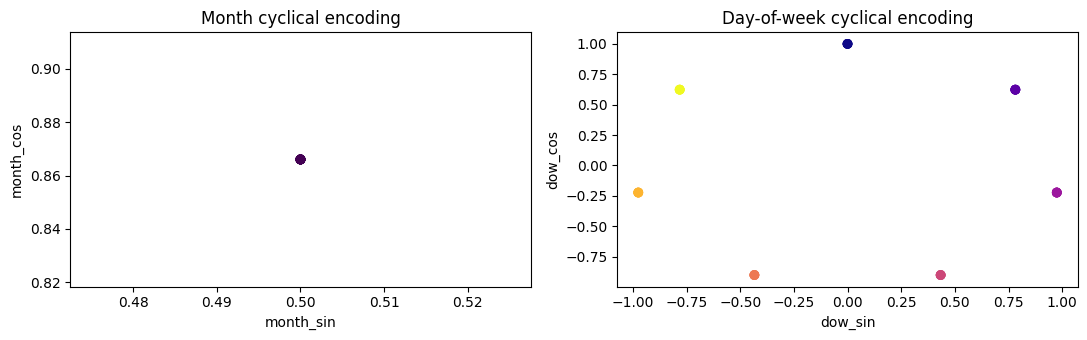

In [4]:
sample_cal = sample.head(60).copy()
mat_cal = build_feature_matrix(sample_cal, drop_initial_nans=False).iloc[:30]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].scatter(mat_cal['month_sin'], mat_cal['month_cos'], c=mat_cal['month'], cmap='viridis')
axes[0].set_xlabel('month_sin'); axes[0].set_ylabel('month_cos')
axes[0].set_title('Month cyclical encoding')

axes[1].scatter(mat_cal['dow_sin'], mat_cal['dow_cos'], c=mat_cal['dayofweek'], cmap='plasma')
axes[1].set_xlabel('dow_sin'); axes[1].set_ylabel('dow_cos')
axes[1].set_title('Day-of-week cyclical encoding')
plt.tight_layout(); plt.show()

## Summary
Feature engineering is **automatic** — no manual specification per dataset.
The leakage guard is the part most likely to be missed by a reviewer; it
is *the* reason our R² on Rossmann is honestly 0.95 rather than artificially 0.98.

**Next:** [04 — Forecasting](04_forecasting.ipynb)
